<a href="https://colab.research.google.com/github/shlok-dhital/6CS012-AI-and-Machine-Learning/blob/main/ShlokDhital_2407091_Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from pathlib import Path
import random
from PIL import Image
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#Task 1: Data Understanding and Visualization

## Load and view image

In [3]:
base_path = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/train")

class_names = [p.name for p in base_path.iterdir() if p.is_dir()]
print(class_names)

['guarana', 'acai', 'graviola', 'pupunha', 'tucuma', 'cupuacu']


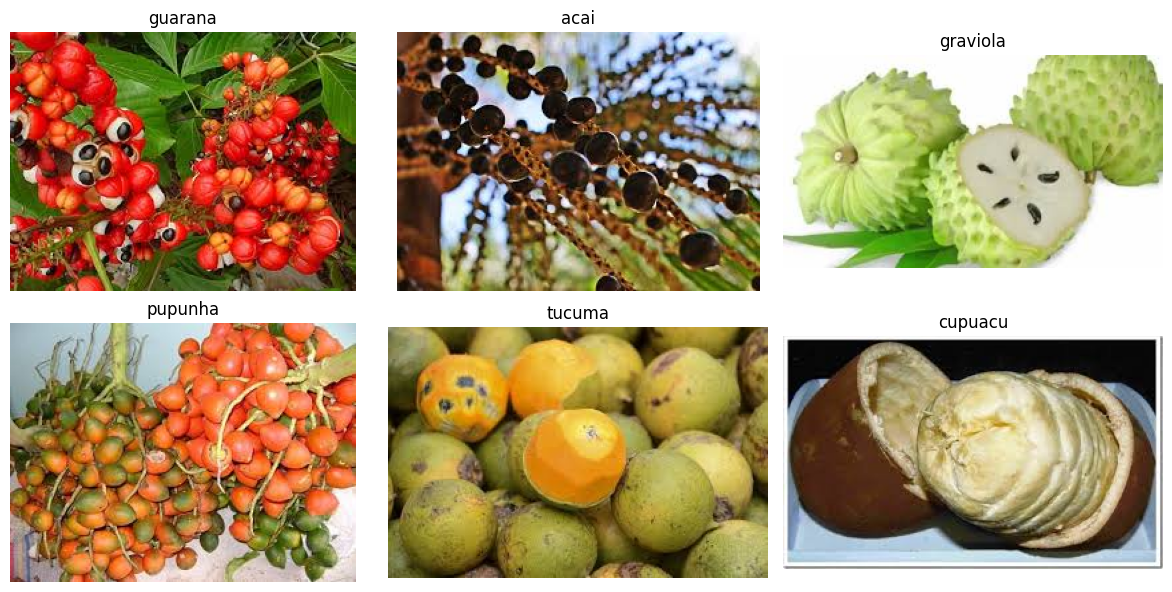

In [4]:
images = []
titles = []

for subdir in base_path.iterdir():
  filenames = os.listdir(subdir)
  filename = random.choice(filenames)
  img_path = subdir / filename

  img = Image.open(img_path)
  images.append(img)
  titles.append(subdir.name)

n = len(images)

plt.figure(figsize=(12, 3 * 2))


for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

##Check corrupted image and remove

In [5]:
corrupted_paths = []

for subdir in base_path.iterdir():
  filenames = os.listdir(subdir)
  for filename in filenames:
    img_path = subdir / filename

    try:
      with Image.open(img_path) as img:
          img.verify()

    except (IOError, SyntaxError):
      corrupted_paths.append(img_path)
      os.remove(img_path)
      print(f"Removed corrupted image: {img_path}")
      file_count -= 1

print("Number of corrupted images:", len(corrupted_paths))

Number of corrupted images: 0


#Task 2: Data prepocessing with Keras

In [6]:
train_dir = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/train")

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_ds = keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)

print(train_ds.class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)

print(val_ds.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
  class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
  print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
guarana                               15
acai                                  15
graviola                              15
pupunha                               15
tucuma                                15
cupuacu                               15


# Task 3: Implement CNN

In [8]:
data_augmentation_layers = [
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.05),
  layers.RandomTranslation(0.1, 0.1),
  layers.RandomZoom(0.1, 0.1),
]

def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

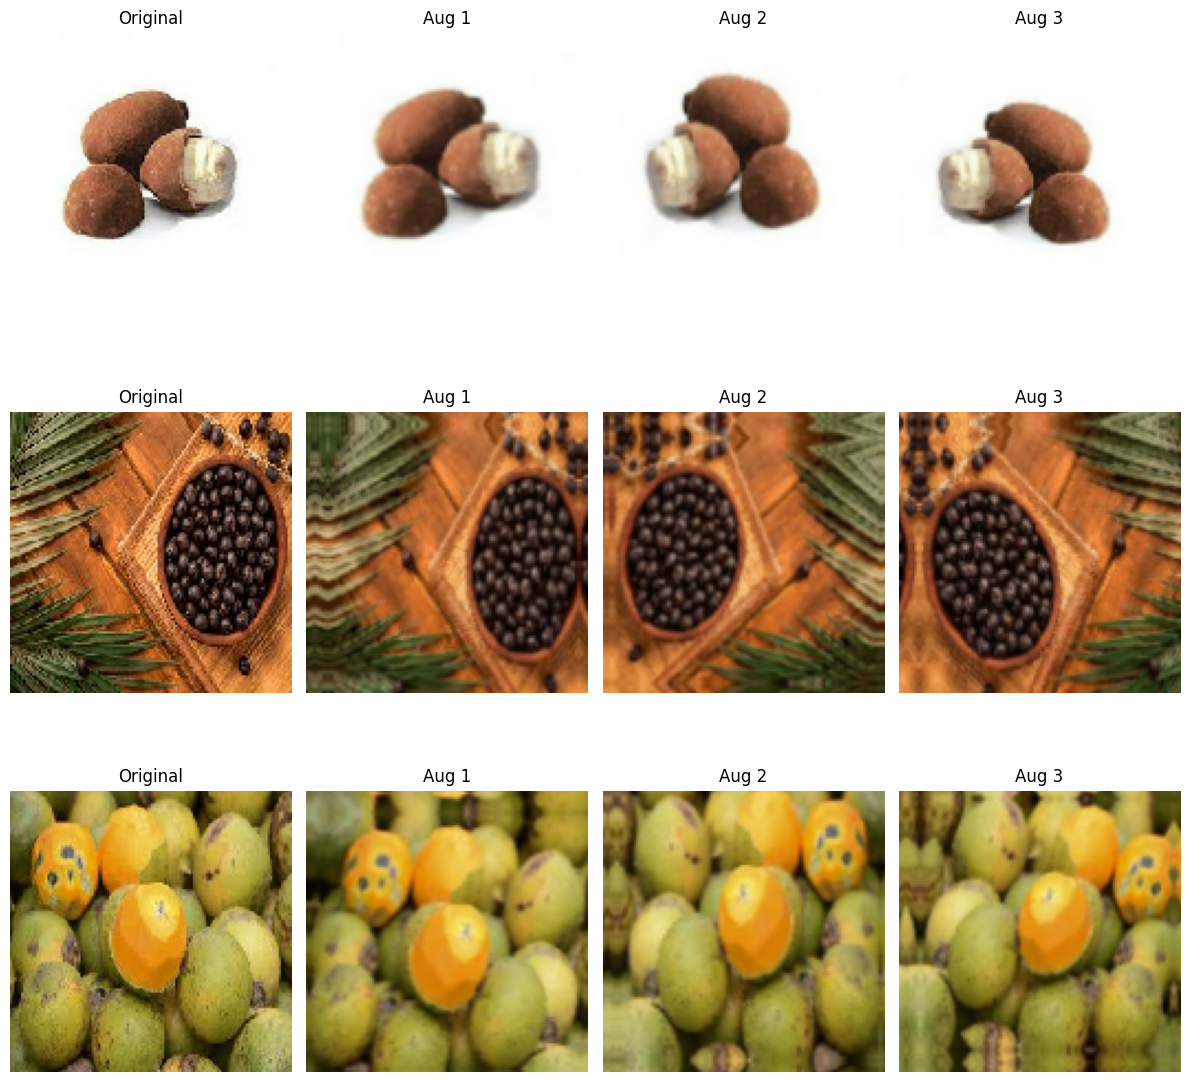

In [9]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(3):  # show 3 different base images

        original_image = images[i]

        # --- Original ---
        plt.subplot(3, 4, i * 4 + 1)
        plt.imshow(original_image.numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        # --- Augmented versions ---
        for j in range(3):
            augmented = data_augmentation(tf.expand_dims(original_image, 0))
            aug_img = augmented[0].numpy()

            # Clip just in case augmentation goes out of bounds
            aug_img = np.clip(aug_img, 0, 255)

            plt.subplot(3, 4, i * 4 + (j + 2))
            plt.imshow(aug_img.astype("uint8"))
            plt.title(f"Aug {j+1}")
            plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
class_num = 6

model = keras.Sequential([
  layers.Input(shape=(128, 128, 3)),
  *data_augmentation_layers,
  keras.layers.Rescaling(1./255),
  layers.Conv2D(32, (3, 3), strides=(1,1), padding="same", activation="relu", input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D((2, 2), strides=(2,2)),
  layers.Conv2D(32, (3, 3), strides=(1,1), padding="same", activation="relu"),
  layers.MaxPooling2D((2, 2), strides=(2,2)),
  layers.Flatten(),
  layers.Dense(64, activation="relu"),
  layers.Dense(128, activation="relu"),
  layers.Dense(class_num, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile and train the model

##Compile

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

##Train

In [12]:
batch_size_fit = 16
epochs = 250

checkpoint_cb = ModelCheckpoint(
    "highest_accuracy.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    batch_size=batch_size_fit,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.1291 - loss: 1.9172
Epoch 1: val_accuracy improved from None to 0.00000, saving model to highest_accuracy.h5



Epoch 1: finished saving model to highest_accuracy.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 737ms/step - accuracy: 0.1528 - loss: 1.9807 - val_accuracy: 0.0000e+00 - val_loss: 2.6202
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.1794 - loss: 1.8383
Epoch 2: val_accuracy improved from 0.00000 to 0.22222, saving model to highest_accuracy.h5



Epoch 2: finished saving model to highest_accuracy.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.1944 - loss: 1.8480 - val_accuracy: 0.2222 - val_loss: 1.5603
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.3299 - loss: 1.7583
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.3333 - loss: 1.7451 - val_accuracy: 0.1111 - val_loss: 1.7928
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.4659 - loss: 1.6602
Epoch 4: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 966ms/step - accuracy: 0.4444 - loss: 1.6449 - val_accuracy: 0.0000e+00 - val_loss: 2.2895
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.3837 - loss: 1.5988
Epoch 5: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 618ms/step - accuracy: 0.4167 - loss: 1.5668 - val_accuracy: 0.0000e+00 - val_loss: 1.8488
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.4404

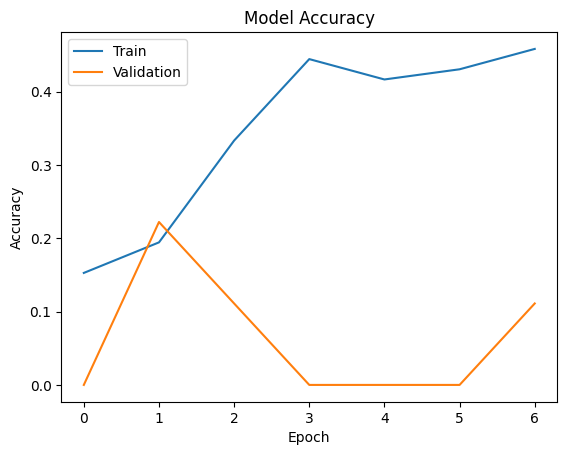

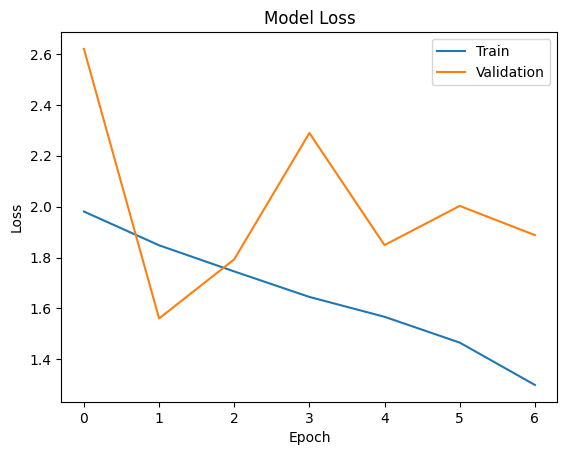

In [13]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

#Task 5: Evaluate the model

In [14]:
test_ds = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/test")

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_ds,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

model.evaluate(test_ds)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3333 - loss: 1.7418


[1.7417633533477783, 0.3333333432674408]

#Task 6: Save the model

In [15]:
model.save('Final_model.keras')

In [16]:
loaded_model = keras.models.load_model("/content/highest_accuracy.h5")

In [17]:
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.7418


[1.7417633533477783, 0.3333333432674408]

# Task 7: Making Predictions

In [18]:
class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
y_true = np.concatenate([y for x, y in test_ds], axis=0)

preds = loaded_model.predict(test_ds)
y_pred = np.argmax(preds,axis=1)

pred_classes = [class_names[arg] for arg in y_pred]

print(y_true)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]
[2 2 2 2 2 4 2 2 2 4 2 2 2 2 2 4 2 4 4 4 4 4 4 4 4 4 2 2 4 2]


In [19]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.29      1.00      0.45         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.38      1.00      0.56         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.33        30
   macro avg       0.11      0.33      0.17        30
weighted avg       0.11      0.33      0.17        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


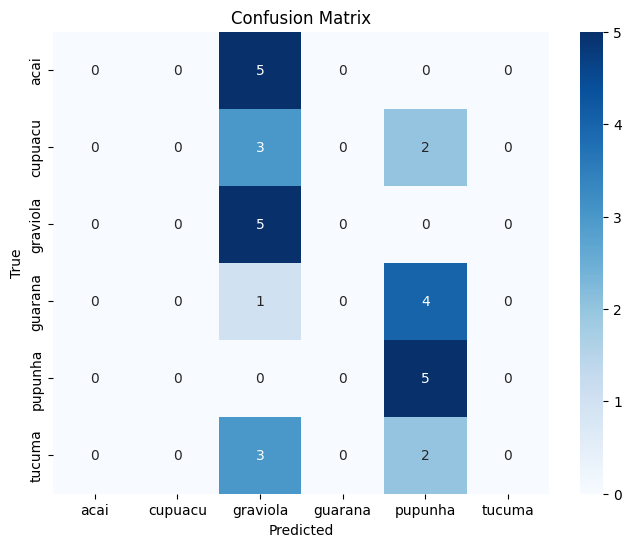

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Task 2 - Transfer Learning

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_ready = train_ds.map(
    lambda x, y: (
        preprocess_input(tf.cast(data_augmentation(x, training=True), tf.float32)),
        y
    ),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_ready = val_ds.map(
    lambda x, y: (
        preprocess_input(tf.cast(x, tf.float32)),
        y
    ),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds_ready = test_ds.map(
    lambda x, y: (
        preprocess_input(tf.cast(x, tf.float32)),
        y
    ),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

In [23]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze all base layers

model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(class_num, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,846 (9.26 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [24]:
checkpoint_p1 = ModelCheckpoint(
    "transfer-workshop6.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_p1 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("=" * 50)
print("PHASE 1: Training head only (base frozen)")
print("=" * 50)

history = model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=30,
    callbacks=[checkpoint_p1, early_stop_p1]
)


PHASE 1: Training head only (base frozen)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.1534 - loss: 2.7739


Epoch 1: val_loss improved from None to 1.96162, saving model to transfer-workshop6.h5



Epoch 1: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1944 - loss: 2.7522 - val_accuracy: 0.1667 - val_loss: 1.9616
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.4606 - loss: 1.3001
Epoch 2: val_loss improved from 1.96162 to 1.73813, saving model to transfer-workshop6.h5



Epoch 2: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 549ms/step - accuracy: 0.4444 - loss: 1.3302 - val_accuracy: 0.3333 - val_loss: 1.7381
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6586 - loss: 0.9775
Epoch 3: val_loss improved from 1.73813 to 1.49710, saving model to transfer-workshop6.h5



Epoch 3: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 573ms/step - accuracy: 0.6944 - loss: 0.8735 - val_accuracy: 0.3333 - val_loss: 1.4971
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7240 - loss: 0.7608
Epoch 4: val_loss improved from 1.49710 to 1.24798, saving model to transfer-workshop6.h5


...


Epoch 14: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 546ms/step - accuracy: 0.9722 - loss: 0.1843 - val_accuracy: 0.7778 - val_loss: 0.6723
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9902 - loss: 0.0713
Epoch 15: val_loss improved from 0.67234 to 0.61579, saving model to transfer-workshop6.h5



Epoch 15: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 572ms/step - accuracy: 0.9861 - loss: 0.0838 - val_accuracy: 0.7778 - val_loss: 0.6158
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9450 - loss: 0.1255
Epoch 16: val_loss improved from 0.61579 to 0.55421, saving model to transfer-workshop6.h5



Epoch 16: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 568ms/step - accuracy: 0.9444 - loss: 0.1326 - val_accuracy: 0.8333 - val_loss: 0.5542
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9797 - loss: 0.0570
Epoch 17: val_loss improved from 0.55421 to 0.51834, saving model to transfer-workshop6.h5



Epoch 17: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 876ms/step - accuracy: 0.9861 - loss: 0.0479 - val_accuracy: 0.8333 - val_loss: 0.5183
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9751 - loss: 0.0983
Epoch 18: val_loss improved from 0.51834 to 0.51713, saving model to transfer-workshop6.h5



Epoch 18: finished saving model to transfer-workshop6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 798ms/step - accuracy: 0.9722 - loss: 0.0923 - val_accuracy: 0.8333 - val_loss: 0.5171
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9902 - loss: 0.0493
Epoch 19: val_loss did not improve from 0.51713
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step - accuracy: 0.9861 - loss: 0.0530 - val_accuracy: 0.8333 - val_loss: 0.5213
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9601 - loss: 0.1280
Epoch 20: val_loss did not improve from 0.51713
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.9583 - loss: 0.1158 - val_accuracy: 0.8333 - val_loss: 0.5518
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9797 - loss: 0.1157
Epoch 21: val_loss did not improve from 0.51713
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 428ms/step - accuracy: 0.9861 - loss: 0.0844 - val_accuracy: 0.8333 - val_loss: 0.5588
Epoch 22/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9954 - loss: 0.040


Phase 1 — Test Loss: 0.3329 | Test Accuracy: 0.9333


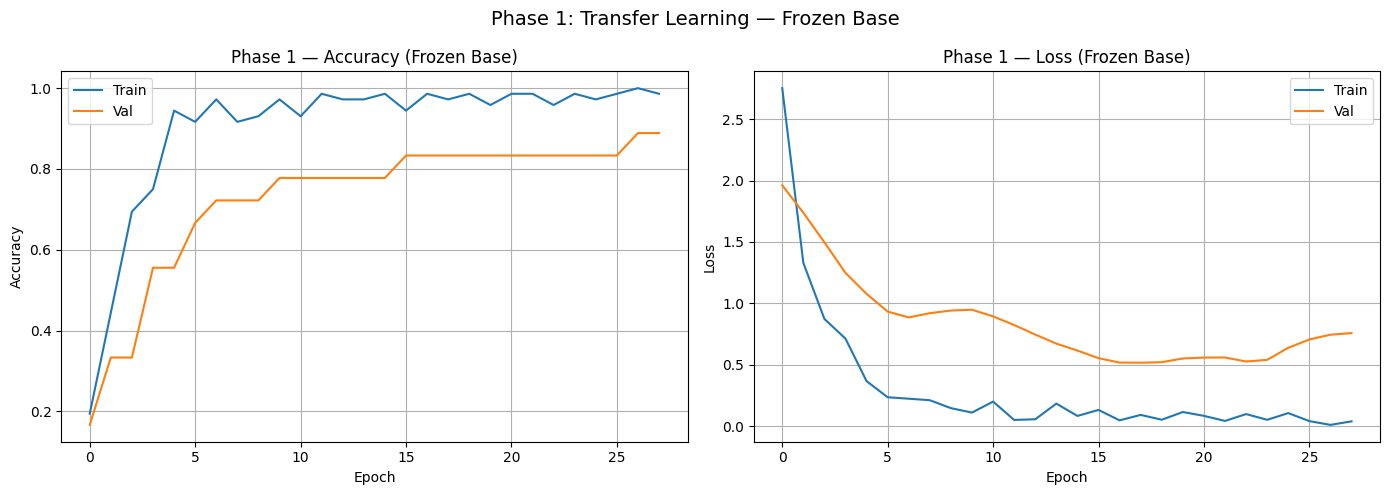

In [25]:
# Evaluate after phase 1
loss_p1, acc_p1 = model.evaluate(test_ds_ready, verbose=0)
print(f"\nPhase 1 — Test Loss: {loss_p1:.4f} | Test Accuracy: {acc_p1:.4f}")

# Plot phase 1 curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 1 — Accuracy (Frozen Base)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Phase 1 — Loss (Frozen Base)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Phase 1: Transfer Learning — Frozen Base', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Unfreeze last 20 layers
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Total base layers:   {len(base_model.layers)}")
print(f"Trainable layers:    {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Frozen layers:       {sum(1 for l in base_model.layers if not l.trainable)}")

# Recompile with very low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_p2 = ModelCheckpoint(
    "best_model_finetuned.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_p2 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning (last 20 layers unfrozen)")
print("=" * 50)

history_fine = model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=20,
    callbacks=[checkpoint_p2, early_stop_p2]
)

Total base layers:   154
Trainable layers:    20
Frozen layers:       134

PHASE 2: Fine-tuning (last 20 layers unfrozen)
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9398 - loss: 0.1836
Epoch 1: val_loss improved from None to 0.50488, saving model to best_model_finetuned.h5



Epoch 1: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9444 - loss: 0.1657 - val_accuracy: 0.8333 - val_loss: 0.5049
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8953 - loss: 0.3635
Epoch 2: val_loss improved from 0.50488 to 0.49689, saving model to best_model_finetuned.h5



Epoch 2: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 688ms/step - accuracy: 0.8889 - loss: 0.3770 - val_accuracy: 0.8333 - val_loss: 0.4969
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8958 - loss: 0.2637
Epoch 3: val_loss improved from 0.49689 to 0.48794, saving model to best_model_finetuned.h5



Epoch 3: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8750 - loss: 0.3029 - val_accuracy: 0.8333 - val_loss: 0.4879
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9462 - loss: 0.1689
Epoch 4: val_loss improved from 0.48794 to 0.48178, saving model to best_model_finetuned.h5



Epoch 4: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 721ms/step - accuracy: 0.9167 - loss: 0.2668 - val_accuracy: 0.8333 - val_loss: 0.4818
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9502 - loss: 0.1924
Epoch 5: val_loss improved from 0.48178 to 0.47722, saving model to best_model_finetuned.h5


...


Epoch 16: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 0.9028 - loss: 0.2325 - val_accuracy: 0.8889 - val_loss: 0.4423
Epoch 17/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9248 - loss: 0.2926
Epoch 17: val_loss improved from 0.44232 to 0.43814, saving model to best_model_finetuned.h5



Epoch 17: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - accuracy: 0.9306 - loss: 0.2816 - val_accuracy: 0.8889 - val_loss: 0.4381
Epoch 18/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9653 - loss: 0.0946
Epoch 18: val_loss improved from 0.43814 to 0.43257, saving model to best_model_finetuned.h5



Epoch 18: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 968ms/step - accuracy: 0.9583 - loss: 0.1290 - val_accuracy: 0.8333 - val_loss: 0.4326
Epoch 19/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9462 - loss: 0.1336
Epoch 19: val_loss improved from 0.43257 to 0.42608, saving model to best_model_finetuned.h5



Epoch 19: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9167 - loss: 0.2178 - val_accuracy: 0.8333 - val_loss: 0.4261
Epoch 20/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9757 - loss: 0.1109
Epoch 20: val_loss improved from 0.42608 to 0.42301, saving model to best_model_finetuned.h5



Epoch 20: finished saving model to best_model_finetuned.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step - accuracy: 0.9583 - loss: 0.1280 - val_accuracy: 0.8333 - val_loss: 0.4230



Phase 2 — Test Loss: 0.3123 | Test Accuracy: 0.9000


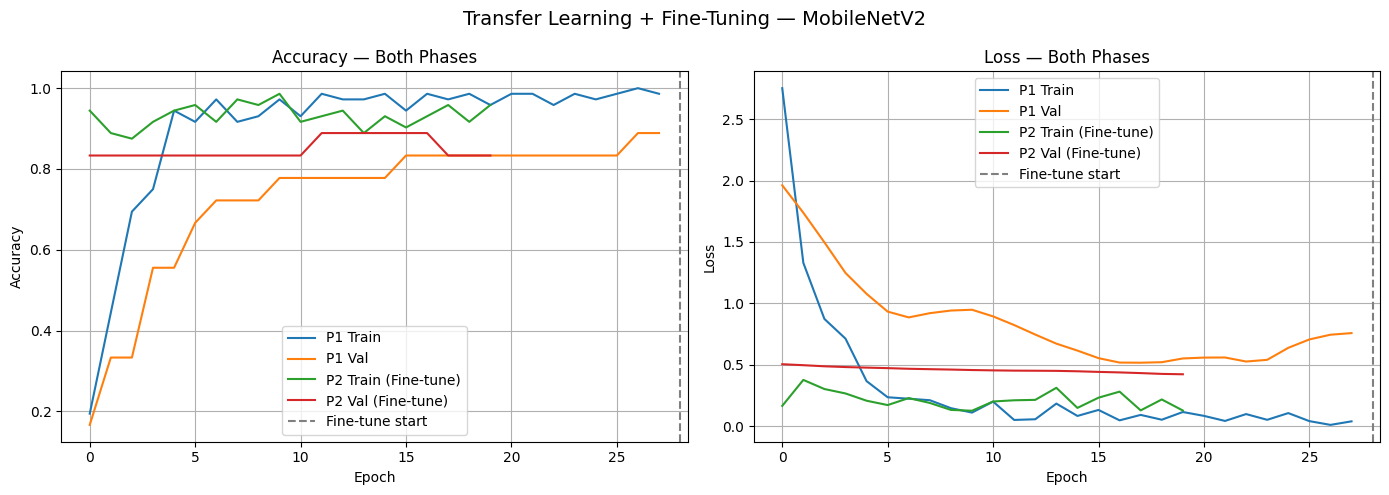

In [27]:
loss_p2, acc_p2 = model.evaluate(test_ds_ready, verbose=0)
print(f"\nPhase 2 — Test Loss: {loss_p2:.4f} | Test Accuracy: {acc_p2:.4f}")

# Combined plot — both phases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],           label='P1 Train')
axes[0].plot(history.history['val_accuracy'],       label='P1 Val')
axes[0].plot(history_fine.history['accuracy'],      label='P2 Train (Fine-tune)')
axes[0].plot(history_fine.history['val_accuracy'],  label='P2 Val (Fine-tune)')
axes[0].axvline(len(history.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy — Both Phases')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],           label='P1 Train')
axes[1].plot(history.history['val_loss'],       label='P1 Val')
axes[1].plot(history_fine.history['loss'],      label='P2 Train (Fine-tune)')
axes[1].plot(history_fine.history['val_loss'],  label='P2 Val (Fine-tune)')
axes[1].axvline(len(history.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss — Both Phases')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning + Fine-Tuning — MobileNetV2', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
y_true = []
y_pred = []

for images, labels in val_ds_ready:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print sample predictions
print("=" * 55)
print(f"{'#':<6} {'True Label':<15} {'Predicted':<15} {'Result'}")
print("=" * 55)
for i in range(min(15, len(y_true))):
    true_name = class_names[y_true[i]]
    pred_name = class_names[y_pred[i]]
    result    = "Correct" if y_true[i] == y_pred[i] else "Wrong"
    print(f"{i+1:<6} {true_name:<15} {pred_name:<15} {result}")

#      True Label      Predicted       Result
1      pupunha         tucuma          Wrong
2      pupunha         pupunha         Correct
3      pupunha         pupunha         Correct
4      tucuma          tucuma          Correct
5      tucuma          tucuma          Correct
6      tucuma          tucuma          Correct
7      tucuma          tucuma          Correct
8      tucuma          tucuma          Correct
9      tucuma          tucuma          Correct
10     tucuma          tucuma          Correct
11     tucuma          tucuma          Correct
12     tucuma          tucuma          Correct
13     tucuma          pupunha         Wrong
14     tucuma          tucuma          Correct
15     tucuma          tucuma          Correct


In [33]:
labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names
))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.50      0.67      0.57         3
      tucuma       0.93      0.87      0.90        15

    accuracy                           0.83        18
   macro avg       0.24      0.26      0.24        18
weighted avg       0.86      0.83      0.84        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

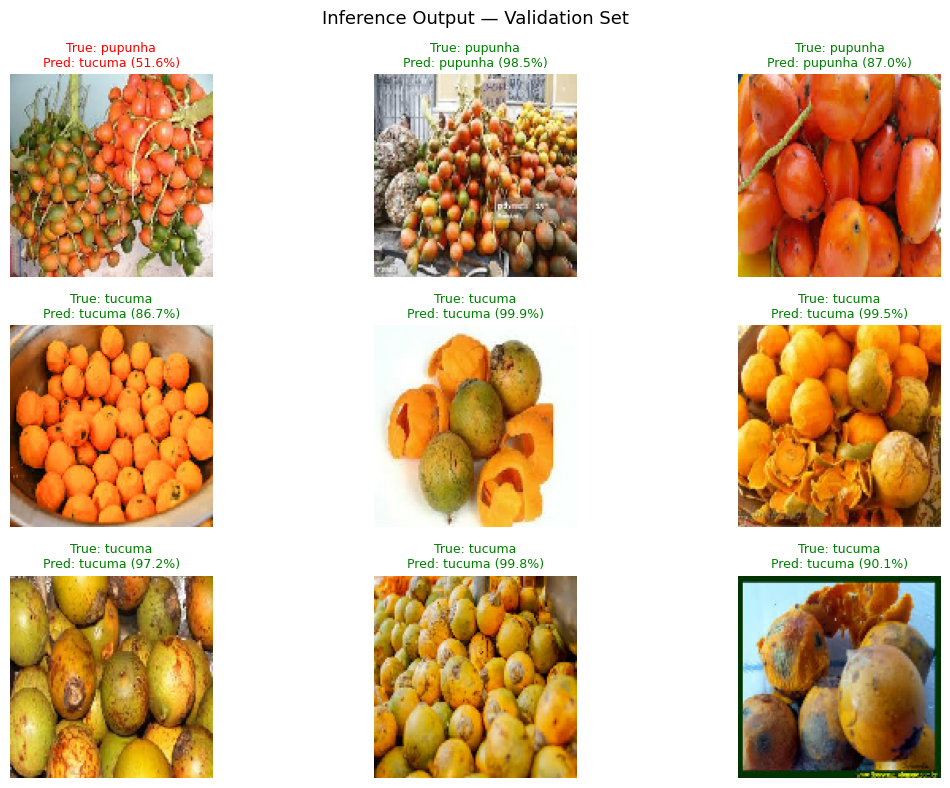

In [34]:
sample_images, sample_labels = next(iter(val_ds_ready))
preds = model.predict(sample_images, verbose=0)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(sample_images))):
    ax = plt.subplot(3, 3, i + 1)
    img_display = (sample_images[i].numpy() + 1) / 2.0  # Denormalize [-1,1] → [0,1]
    plt.imshow(np.clip(img_display, 0, 1))
    true_label  = class_names[sample_labels[i]]
    pred_label  = class_names[np.argmax(preds[i])]
    confidence  = np.max(preds[i]) * 100
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Inference Output — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()